In [1]:
# For google colab
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/Othercomputers/My Mac/DeepElig/KP/src/')
colab=True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!python '/content/drive/Othercomputers/My Mac/DeepElig/KP/src/SpeechPreprocess.py'


100% 2.26G/2.26G [00:17<00:00, 137MB/s]

Processing training
100% 84849/84849 [09:58<00:00, 141.88it/s]
Label distribution:
{'backward': 1346, 'bed': 1594, 'bird': 1697, 'cat': 1657, 'dog': 1711, 'down': 3134, 'eight': 3033, 'five': 3240, 'follow': 1275, 'forward': 1256, 'four': 2955, 'go': 3106, 'happy': 1632, 'house': 1727, 'learn': 1286, 'left': 3037, 'marvin': 1710, 'nine': 3170, 'no': 3130, 'off': 2970, 'on': 3086, 'one': 3140, 'right': 3019, 'seven': 3205, 'sheila': 1606, 'six': 3088, 'stop': 3111, 'three': 2966, 'tree': 1407, 'two': 3111, 'up': 2948, 'visual': 1288, 'wow': 1724, 'yes': 3228, 'zero': 3250}

Processing validation
100% 9981/9981 [01:12<00:00, 137.72it/s]
Label distribution:
{'backward': 153, 'bed': 213, 'bird': 182, 'cat': 180, 'dog': 197, 'down': 377, 'eight': 346, 'five': 367, 'follow': 132, 'forward': 146, 'four': 373, 'go': 372, 'happy': 219, 'house': 195, 'learn': 128, 'left': 352, 'marvin': 195, 'nine': 356, 'no': 406, 'off': 373, 'on': 363, 'one': 351, 'righ

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import json
import sys
import os
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsSpeech import *

import torchaudio
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

In [3]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

cpu


## Prepare dataloader

Shape of waveform: torch.Size([1, 15018])
Sample rate of waveform: 16000


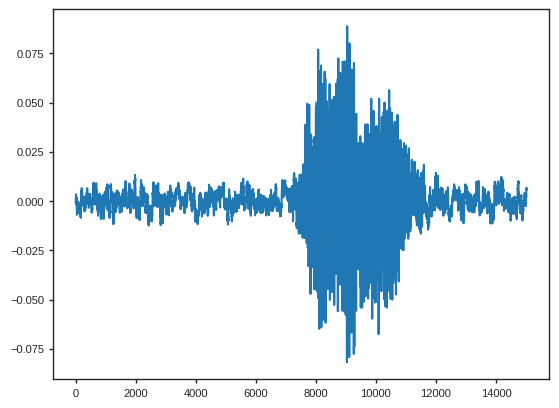

In [4]:
# Create training and testing split of the data. We do not use validation in this tutorial.
val_set = SubsetSC("validation")

waveform, sample_rate, label, speaker_id, utterance_number = val_set[0]
data_config['sample_rate'] = sample_rate

print("Shape of waveform: {}".format(waveform.size()))
print("Sample rate of waveform: {}".format(sample_rate))

plt.plot(waveform.t().numpy());

In [5]:
import IPython.display as ipd
print(label)
ipd.Audio(waveform.numpy(), rate=sample_rate)

right


In [ ]:
!ls

In [6]:
del val_set
data_config["n_steps"] = int(data_config["duration"]/dt)
data_config["n_class"] = len(labels)
n_class = data_config["n_class"]
n_steps = data_config["n_steps"]
answer_steps = int(model_config["answer_period"]/dt)

train_set = MelDataset(dir+'/train')
val_set = MelDataset(dir+'/validation')

if device == "cuda":
    num_workers = train_config['num_workers']
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=train_config['batch_size'],
    shuffle=True,
    #sampler=sampler,
    collate_fn=CollateMel(n_steps),
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=CollateMel(n_steps),
    num_workers=num_workers,
    pin_memory=pin_memory,
)

train_config["batches_per_epoch"] = len(train_loader)

TypeError: unsupported operand type(s) for +: 'builtin_function_or_method' and 'str'

In [ ]:
# if data_config['preprocessing']=='Mel':
#     transform = torchaudio.transforms.MelSpectrogram(
#         sample_rate=data_config['sample_rate'],
#         n_fft=data_config['n_fft'],
#         win_length=data_config['win_length'],
#         hop_length=data_config['hop_length'],
#         n_mels=data_config['n_mels'],
#         center=True
#     )
# elif data_config['preprocessing']=='Raw':
#     new_sample_rate = 10000
#     transform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)

# transformed = transform(waveform)[:, :, :-1]

# data_config["final_seq_length"] = transformed.shape[-1]
# data_config["n_class"] = len(labels)
# n_class = data_config["n_class"]
# n_steps = data_config["final_seq_length"]
# answer_steps = int(model_config["answer_period"]/dt)

# word_start = "yes"
# index = label_to_index(word_start)
# word_recovered = index_to_label(index)

# print(word_start, "-->", index, "-->", word_recovered,
#       ", transformed shape:", transformed.shape, ", Number of steps:", n_steps)

yes --> tensor(33) --> yes , transformed shape: torch.Size([1, 64, 500]) , Number of steps: 500


## Training

In [ ]:
model_config['n_out'] = data_config['n_class']
model_config['n_in'] = data_config['n_mels']
# init network and optimizer
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.6,
    patience=2
)

transform = transform.to(device)
beta = torch.zeros(n_steps).to(model.device)
#beta[n_steps-answer_steps:40] = torch.linspace(0, 1, 40+answer_period-n_steps)
beta[-answer_steps:]=1.
beta /= beta.sum()

best_val_acc = 0.

tensor([ 9., 24.,  4., 16.])


In [ ]:
print("Training started...")
with torch.no_grad():
    loss_record = []
    for epoch in range(train_config["num_epochs"]):
        Cum_errors=0.
        pbar = tqdm(
            enumerate(train_loader, 0),
            total=train_config["batches_per_epoch"],
            disable=not general_config["verbose"],
        )
        for batch_idx, (x, target) in pbar:
            x = transform(x.to(device))[:,0,:,:-1]
            y = F.one_hot(target, num_classes=n_class).to(device)
            # total_error = train_batch_delay(model, optimizer, x,
            #                                 y, answer_steps, beta)
            # Cum_errors += total_error

        Cum_errors /= len(train_loader.dataset)

        val_acc, val_loss = test(model, val_loader, n_class,
                                answer_steps, beta)
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state_dict = model.state_dict().copy()

        print(
            f"Epoch: {epoch+1}, "
            f'Train Loss: {Cum_errors:.4f},'
            f'Test Loss: {val_loss:.4f},'
            f'Test Acc: {val_acc:.1f},'
            f'Best Acc: {best_val_acc:.1f},'
        )
        pbar.close()

print('finished')

Training started...


  3%|██                                                                               | 17/663 [00:21<13:38,  1.27s/it]


KeyboardInterrupt: 

In [ ]:
for l in model.layers[:2]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

In [ ]:
#TEST
acc, loss = test(model, x_test.to(device), y_test.to(device), 1.4*answer_period)
print('Test Accuracy: ', acc, "Test Loss", loss)

In [ ]:
kernel_record_post = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

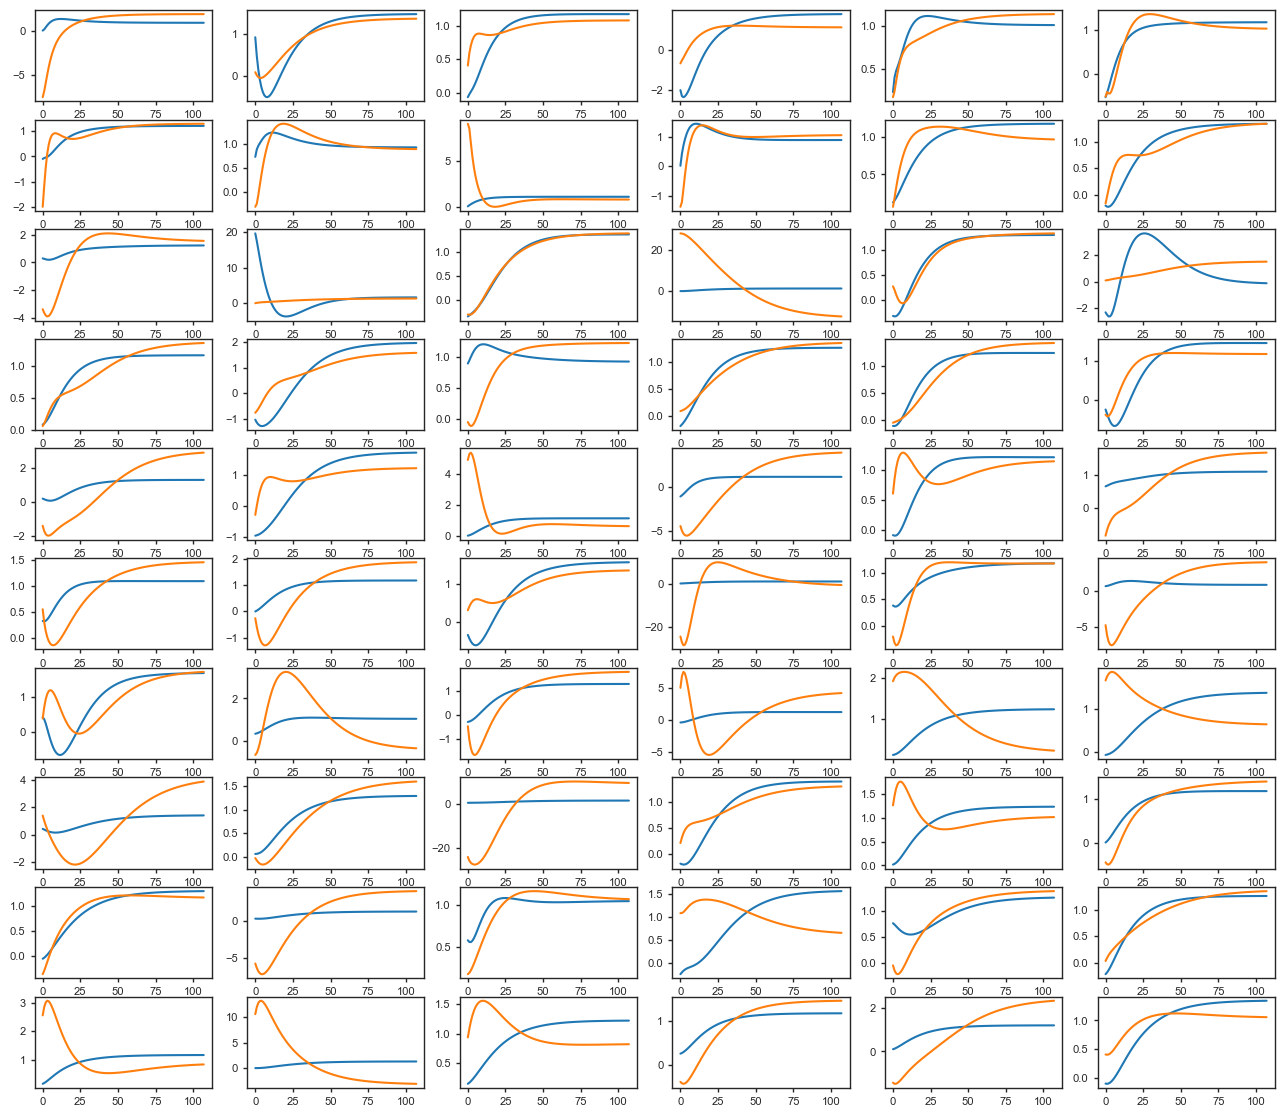

In [ ]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

## Evaluation

In [ ]:
if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

test_set = SubsetSC("testing")
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=100,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

In [ ]:
def number_of_correct(pred, target):
    # count number of correct predictions
    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):
    # find most likely label index for each element in the batch
    return tensor.argmax(dim=-1)




In [ ]:
def predict(tensor):
    # Use the model to predict the label of the waveform
    tensor = tensor.to(device)
    tensor = transform(tensor)
    tensor = model(tensor.unsqueeze(0))
    tensor = get_likely_index(tensor)
    tensor = index_to_label(tensor.squeeze())
    return tensor


waveform, sample_rate, utterance, *_ = train_set[-1]
ipd.Audio(waveform.numpy(), rate=sample_rate)

print(f"Expected: {utterance}. Predicted: {predict(waveform)}.")

In [ ]:
for i, (waveform, sample_rate, utterance, *_) in enumerate(test_set):
    output = predict(waveform)
    if output != utterance:
        ipd.Audio(waveform.numpy(), rate=sample_rate)
        print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")
        break
else:
    print("All examples in this dataset were correctly classified!")
    print("In this case, let's just look at the last data point")
    ipd.Audio(waveform.numpy(), rate=sample_rate)
    print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")

In [ ]:
Saved_model = Path("..") / "saved_models" / "Speech95.6"
with open(Saved_model / "general_config.json") as f:
    general_config = json.load(f)
with open(Saved_model / "model_config.json") as f:
    model_config = json.load(f)
with open(Saved_model / "data_config.json") as f:
    data_config = json.load(f)

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
data = make_dataset(ObjectView(data_config))
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)

dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)
pad_steps = int(data_config["prepad"]/dt/2)

model = buildMNISTNet(model_config, general_config).to(device)
state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device)
print(model.load_state_dict(state_dict))
print(model_config)

beta = torch.zeros(n_steps).to(model.device)
beta[-answer_steps:]=1.
beta /= beta.sum()

tensor([ 1.,  8., 12.,  2.,  7.,  3.,  6.])
<All keys matched successfully>
{'Ins_size': [120], 'LP_size': [60, 90, 90, 90], 'Tau0': [1, 10, 6], 'Tau1': [3, 6], 'Tau2': [2, 7], 'Tau3': [1, 8.0, 12.0], 'activation': 'tanh', 'answer_period': 360, 'n_in': 1, 'n_out': 10, 'num_Ins_layers': 1, 'num_LP_layers': 4, 'reducedNonlinear': False}


In [ ]:
general_config

{'device': 'cpu',
 'dt': 1.0,
 'seed': 89,
 'short_training_run': False,
 'visual_kernel': False}

In [ ]:
test_acc, test_acc_r, test_acc_m = test_mul(model, x_test.to(device), y_test.to(device), answer_steps, pad_steps, beta)

In [ ]:
print(test_acc, test_acc_r, test_acc_m)

95.6 94.9 81.1


## Train BPTT

In [ ]:
#### With P learning ###
dt = general_config["dt"]
n_steps = data_config["final_seq_length"]

# init both teacher and student net
batch = train_config["batch_size"]

model = buildMNISTNet(model_config, general_config).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,#train_config["learning_rate"]
    weight_decay=0.
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.8,
    patience=4
)
loss_fn = torch.nn.CrossEntropyLoss()

kernel_record_pre = extract_kernel(model, n_steps=int(1.5*data_config["final_seq_length"]), layer_idx=model_config["num_LP_layers"])

tensor([ 0.7000,  2.1000,  4.4000, 16.4000, 20.4000,  0.5000,  2.0000,  3.0000])


In [ ]:
num_epochs = 160
Cum_errors = 0.5
error_record = []
for epoch in range(num_epochs):
    permu = np.random.permutation(4000).reshape(-1, batch)
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        sample = x[idx].to(model.device)
        total_error = 0.
        one_hot_label = F.one_hot(y[idx], num_classes=10).type(torch.FloatTensor).to(model.device)
        model.reset()
        prex = torch.zeros(sample.shape[0], 1).to(model.device)
        for t in range(start_steps):
            r_out,_ = model.step(prex)
        for t in range(n_steps):
            r_out,_ = model.step(sample[:, t])
            if n_steps-t <= answer_period:
                total_error += loss_fn(r_out, one_hot_label)/answer_period
        total_error.backward()
        optimizer.step()
        optimizer.zero_grad()

        Cum_errors = 0.95*Cum_errors + 0.05*total_error.detach()

    test_acc, test_loss = test(model, x_test.to(model.device), y_test.to(model.device),
                               answer_steps, start_steps, beta)
    scheduler.step(test_loss)
    error_record.append(Cum_errors)
    print("Train loss: %3f, Test acc: %2f, Epoch: %d"%(Cum_errors, test_acc, epoch+1))

print('finished')

100%|██████████| 40/40 [00:11<00:00,  3.42it/s]


Train loss: 1.869681, Test acc: 0.324000, Epoch: 1


100%|██████████| 40/40 [00:11<00:00,  3.57it/s]


Train loss: 1.904399, Test acc: 0.384000, Epoch: 2


100%|██████████| 40/40 [00:11<00:00,  3.62it/s]


...

Train loss: 1.126040, Test acc: 0.827000, Epoch: 115


100%|██████████| 40/40 [00:11<00:00,  3.48it/s]


Train loss: 1.093787, Test acc: 0.855000, Epoch: 116


 68%|██████▊   | 27/40 [00:08<00:03,  3.33it/s]


KeyboardInterrupt: 

## Check GLE

In [ ]:
#### With P learning ###
dt = general_config["dt"]
n_steps = data_config["final_seq_length"]
answer_period = 48

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

model = buildMNISTNetCompare(model_config, general_config, neurontype='RF').to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,#train_config["learning_rate"],
    betas=(0.95, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.85,
    patience=2
)

kernel_record_pre = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

beta = torch.zeros(n_steps)
beta[-answer_period:]=1.
beta /= beta.sum()
beta.to(model.device)

error_record = []
Cum_errors = 0.5

cpu


In [ ]:
num_epochs = 100

with torch.no_grad():
    for epoch in range(num_epochs):
        permu = np.random.permutation(4000).reshape(-1, batch)
        pbar = tqdm(
            permu,
            total=permu.shape[0],
        )
        for idx in pbar:
            total_error = train_batch(model, optimizer, x[idx], y[idx], answer_period, beta)
            Cum_errors = 0.95*Cum_errors + 0.05*total_error

        test_acc, test_loss = test(model, x_test, y_test, answer_period, beta)
        scheduler.step(test_loss)
        error_record.append(Cum_errors)
        print("Train loss: %3f, Test acc: %2f, Epoch: %d"%(Cum_errors, test_acc, epoch+1))

print('finished')

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 18.59it/s]


Train loss: 0.220171, Test acc: 0.196000, Epoch: 1


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 18.38it/s]


Train loss: 0.216655, Test acc: 0.223000, Epoch: 2


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 18.46it/s]


...

Train loss: 0.201541, Test acc: 0.278000, Epoch: 52


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 18.34it/s]


Train loss: 0.202320, Test acc: 0.307000, Epoch: 53


 66%|██████████████████████████████████████████████████████                            | 66/100 [00:03<00:01, 18.30it/s]


KeyboardInterrupt: 